# Bluestock Mutual Fund EDA
Daily NAV, fund-house AUM, SIP flows, investor demographics, folios, correlations, and portfolio sectors. All source paths are resolved with `pathlib.Path`.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import kaleido

In [2]:
BASE_DIR = Path.cwd().parent
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

funds = pd.read_csv(RAW_DIR / "01_fund_master.csv")
nav = pd.read_csv(PROCESSED_DIR / "02_nav_history_clean.csv")
aum = pd.read_csv(RAW_DIR / "03_aum_by_fund_house.csv")
sip = pd.read_csv(RAW_DIR / "04_monthly_sip_inflows.csv")
category_inflows = pd.read_csv(RAW_DIR / "05_category_inflows.csv")
folio_count = pd.read_csv(RAW_DIR / "06_industry_folio_count.csv")
performance = pd.read_csv(PROCESSED_DIR / "07_scheme_performance_clean.csv")
transactions = pd.read_csv(PROCESSED_DIR / "08_investor_transactions_clean.csv")
holdings = pd.read_csv(RAW_DIR / "09_portfolio_holdings.csv")
benchmark = pd.read_csv(RAW_DIR / "10_benchmark_indices.csv")

print("Funds:", funds.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category inflows:", category_inflows.shape)
print("Folio count:", folio_count.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Holdings:", holdings.shape)
print("Benchmark:", benchmark.shape)

Funds: (40, 15)
NAV: (64320, 3)
AUM: (90, 5)
SIP: (48, 6)
Category inflows: (144, 3)
Folio count: (21, 6)
Performance: (40, 20)
Transactions: (32778, 13)
Holdings: (322, 8)
Benchmark: (8050, 3)


## 1. NAV trend for all schemes

In [3]:
nav_plot = nav.merge(funds[["amfi_code", "scheme_name"]], on="amfi_code", how="left")
nav_plot["date"] = pd.to_datetime(nav_plot["date"], errors="coerce")

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend - All 40 Mutual Fund Schemes",
    labels={"date": "Date", "nav": "NAV", "scheme_name": "Scheme"}
)
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.08, line_width=0)
fig.add_vrect(x0="2024-01-01", x1="2024-12-31", fillcolor="red", opacity=0.08, line_width=0)
fig.add_annotation(x="2023-06-30", y=nav_plot["nav"].max(), text="2023 Bull Run", showarrow=False)
fig.add_annotation(x="2024-06-30", y=nav_plot["nav"].max() * 0.9, text="2024 Market Correction", showarrow=False)

plt.figure(figsize=(16, 9))
for scheme_name, scheme_data in nav_plot.groupby("scheme_name"):
    plt.plot(scheme_data["date"], scheme_data["nav"], linewidth=0.8, alpha=0.7, label=scheme_name)
plt.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"), color="green", alpha=0.08)
plt.axvspan(pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31"), color="red", alpha=0.08)
plt.title("Daily NAV Trend - All 40 Mutual Fund Schemes")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "nav_trend_all_schemes.png", dpi=220, bbox_inches="tight")
plt.close()
fig.show()

**Insight:** NAV values moved upward overall, with visible market changes in 2023 and 2024.  

## 2. Fund-house AUM

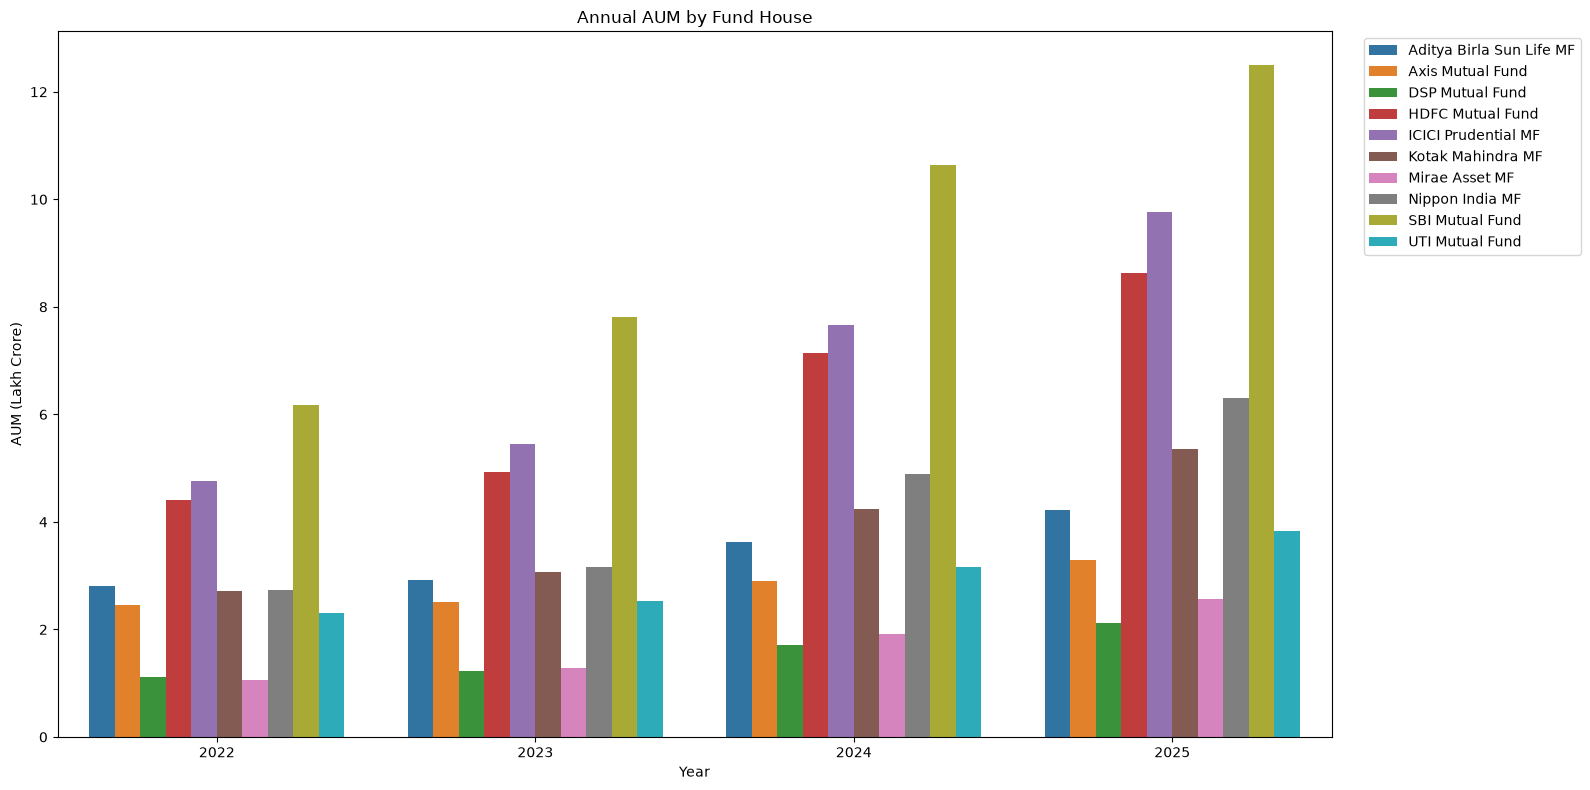

In [4]:
aum = aum.copy()
aum["date"] = pd.to_datetime(aum["date"], errors="coerce")
aum["year"] = aum["date"].dt.year
aum_yearly = (aum[aum["year"].between(2022, 2025)]
              .groupby(["year", "fund_house"], as_index=False)["fund_house_aum_lakh_crore"].mean())

plt.figure(figsize=(16, 8))
sns.barplot(
    data=aum_yearly,
    x="year",
    y="fund_house_aum_lakh_crore",
    hue="fund_house"
)

plt.title("Annual AUM by Fund House")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

sbi = aum_yearly[aum_yearly["fund_house"].eq("SBI Mutual Fund")]
for _, row in sbi.iterrows():
    plt.annotate(
        f"SBI {row['fund_house_aum_lakh_crore']:.1f}L Cr",
        (row["year"], row["fund_house_aum_lakh_crore"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

plt.savefig(REPORTS_DIR / "eda_aum_growth_fund_house.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** SBI Mutual Fund had the highest AUM among the fund houses shown.

## 3. SIP and category flows

In [5]:
sip_plot = sip[(sip["month"] >= "2022-01-01") &(sip["month"] <= "2025-12-31")].copy()

fig = px.line(
    sip_plot,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows — 2022 to 2025",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

peak_row = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=peak_row["month"],
    y=peak_row["sip_inflow_crore"],
    text=f'All-Time High: ₹{peak_row["sip_inflow_crore"]:,.0f} Cr',
    showarrow=True,
    arrowhead=2
)

fig.update_layout(height=600)

plt.savefig(REPORTS_DIR / "eda_sip_inflow_trend.png")
fig.show()

<Figure size 640x480 with 0 Axes>

**Insight:** SIP inflows reached their highest level in one month during the period.  

## 4. Category Inflow Heatmap

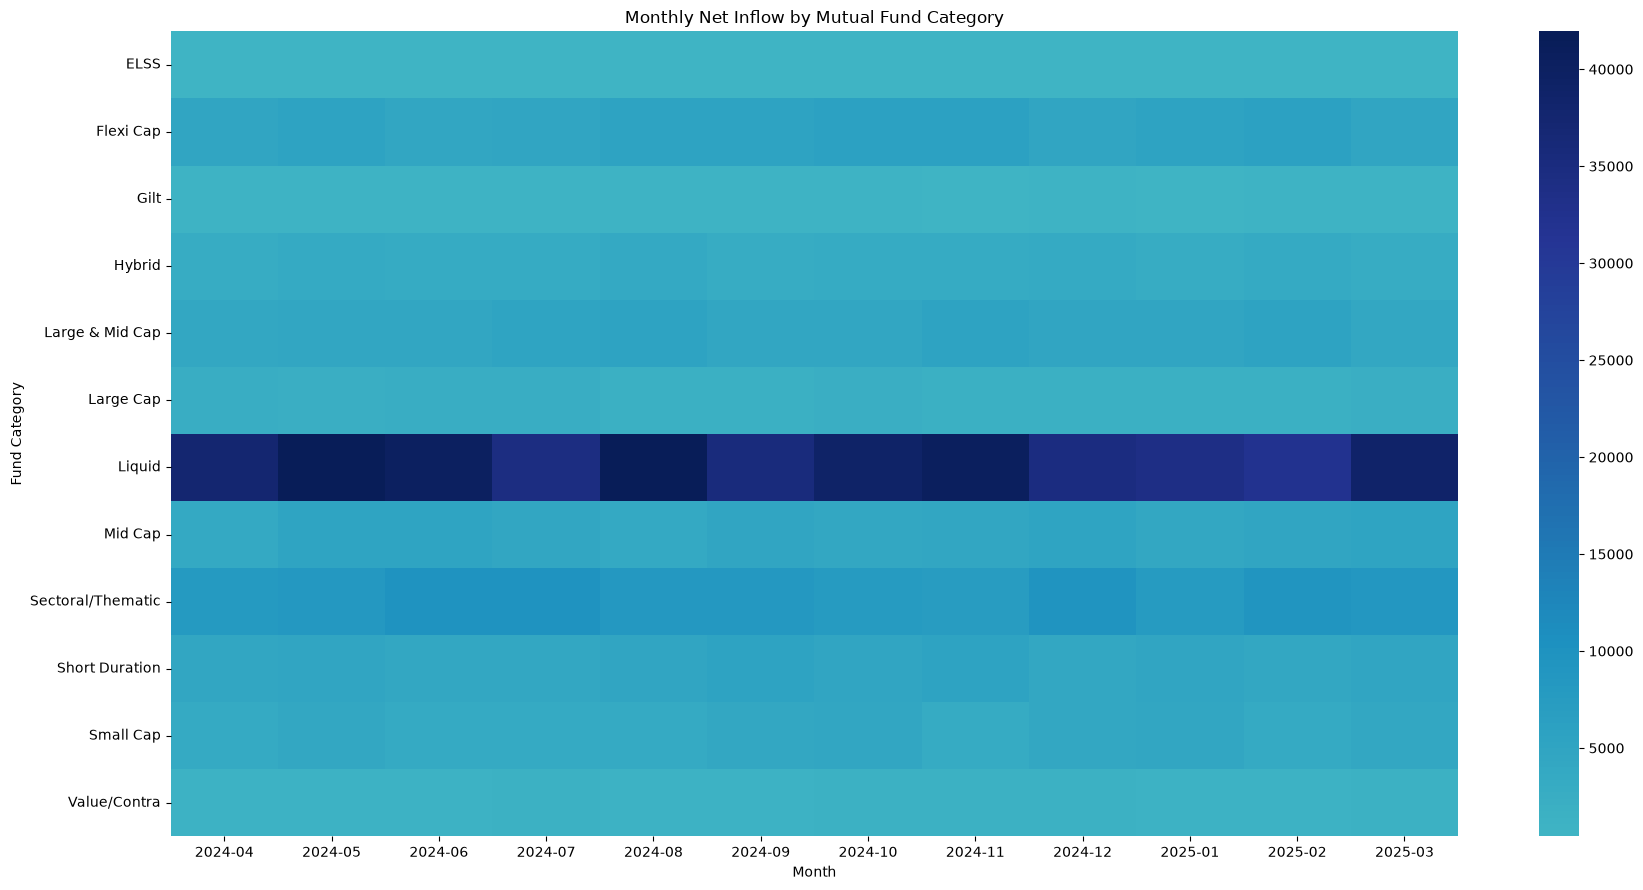

In [6]:
category_pivot = category_inflows.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(18, 9))
sns.heatmap(
    category_pivot,
    cmap="YlGnBu",
    center=0
)

plt.title("Monthly Net Inflow by Mutual Fund Category")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "eda_category_inflow_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** Net inflows varied across categories and months.  

## 5. Investor demographics

In [7]:
age_distribution = transactions["age_group"].value_counts().reset_index()
age_distribution.columns = ["age_group", "count"]

fig = px.pie(age_distribution, names="age_group", values="count", title="Investor Distribution by Age Group")

plt.figure(figsize=(9, 7))
plt.pie(age_distribution["count"], labels=age_distribution["age_group"], autopct="%1.1f%%", startangle=90)
plt.title("Investor Distribution by Age Group")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_age_distribution.png", dpi=220, bbox_inches="tight")
plt.close()
fig.show()

**Insight:** Investors are distributed across several age groups.  

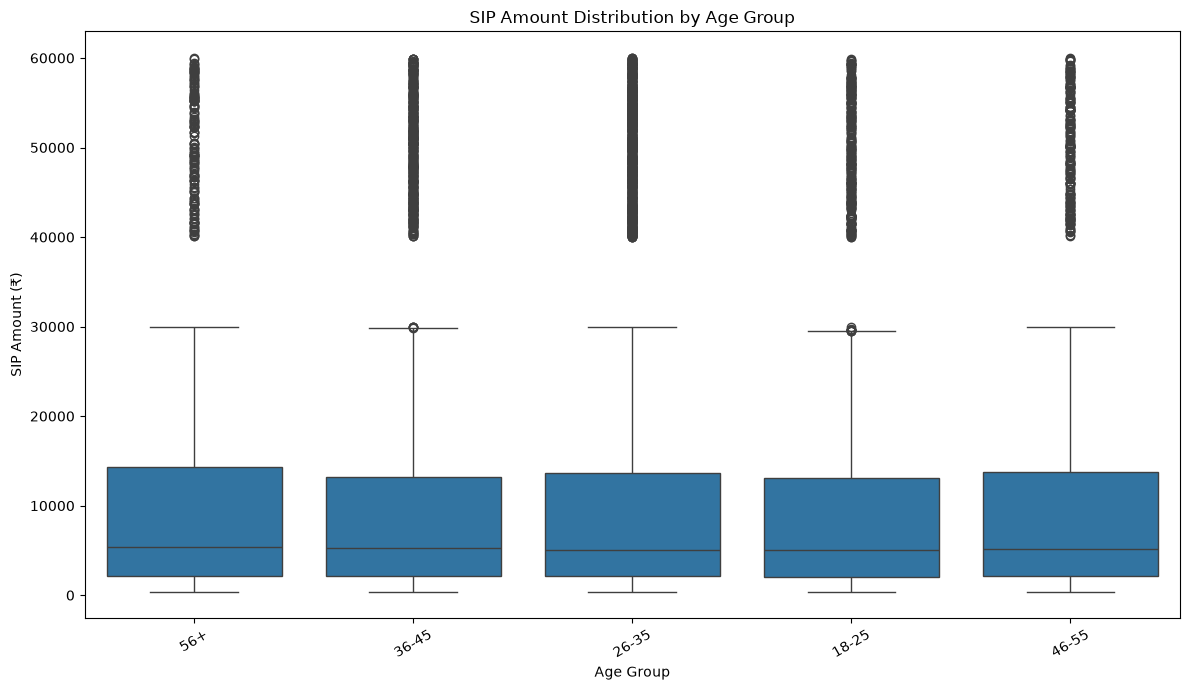

In [8]:
sip_age = transactions[transactions["transaction_type"] == "SIP"].copy()

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=sip_age,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(REPORTS_DIR / "eda_sip_amount_age_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** SIP amounts differ across investor age groups.

## 6. Geographic distribution

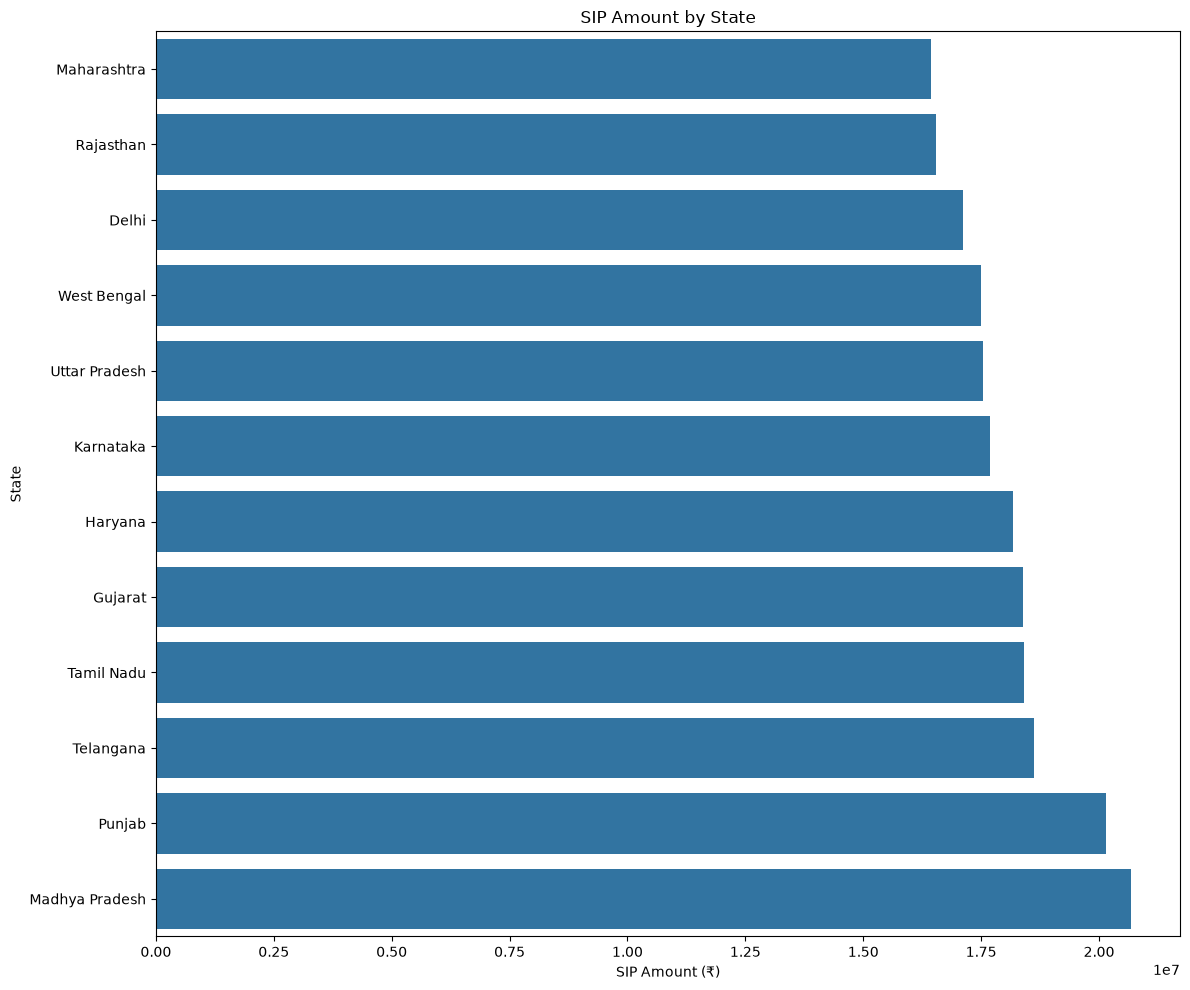

In [9]:
sip_state = (transactions[transactions["transaction_type"] == "SIP"].groupby("state", as_index=False)["amount_inr"]
             .sum().sort_values("amount_inr", ascending=True))

plt.figure(figsize=(12, 10))
sns.barplot(
    data=sip_state,
    x="amount_inr",
    y="state"
)

plt.title("SIP Amount by State")
plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "eda_sip_amount_state.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** SIP contributions were higher in a few leading states.  

## 7. Folio growth

In [10]:
folio_plot = folio_count[(folio_count["month"] >= "2022-01-01") & (folio_count["month"] <= "2025-12-31")].copy()

fig = px.line(
    folio_plot,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Folio Growth - 2022 to 2025",
    labels={"month": "Month", "total_folios_crore": "Folios (Crore)"}
)
milestone_rows = folio_plot.iloc[[0, len(folio_plot)//4, len(folio_plot)//2, 3*len(folio_plot)//4, len(folio_plot)-1]]

plt.figure(figsize=(14, 8))
plt.plot(folio_plot["month"], folio_plot["total_folios_crore"], marker="o", linewidth=2)
plt.scatter(milestone_rows["month"], milestone_rows["total_folios_crore"], color="crimson", zorder=3)
for _, row in milestone_rows.iterrows():
    plt.annotate(f'{row["total_folios_crore"]:.2f} Cr', (row["month"], row["total_folios_crore"]), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=8)
plt.title("Mutual Fund Folio Growth - 2022 to 2025")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_folio_growth.png", dpi=220, bbox_inches="tight")
plt.close()
fig.show()

**Insight:** The number of mutual fund folios increased over time.

## 8. Return correlation and portfolio sectors

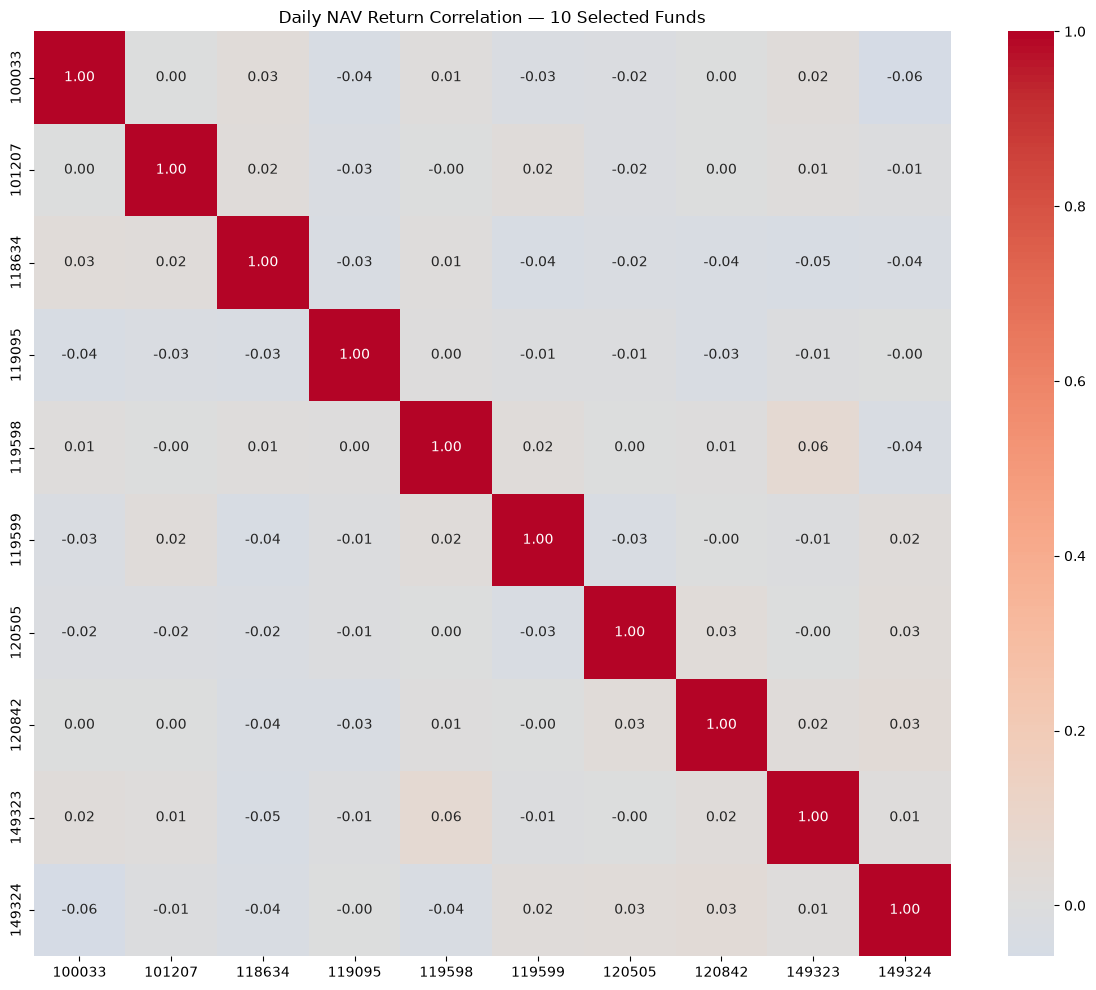

In [11]:
selected_codes = (performance.sort_values("return_3yr_pct", ascending=False)["amfi_code"].head(10).tolist())
nav_selected = nav[nav["amfi_code"].isin(selected_codes)].copy()
nav_selected = nav_selected.sort_values(["amfi_code", "date"])
nav_selected["daily_return"] = (nav_selected.groupby("amfi_code")["nav"].pct_change())

return_matrix = nav_selected.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

correlation_matrix = return_matrix.corr()
correlation_matrix.columns = [str(x) for x in correlation_matrix.columns]
correlation_matrix.index = [str(x) for x in correlation_matrix.index]

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Daily NAV Return Correlation — 10 Selected Funds")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "eda_nav_return_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** The selected funds show different levels of return correlation.

## 9. Sector Allocation

In [12]:
equity_funds = funds[funds["category"].astype(str).str.contains("Equity", case=False, na=False)][["amfi_code"]]
equity_holdings = holdings.merge(equity_funds, on="amfi_code", how="inner")
sector_allocation = equity_holdings.groupby("sector", as_index=False)["weight_pct"].sum().sort_values("weight_pct", ascending=False)

fig = px.pie(sector_allocation, names="sector", values="weight_pct", title="Aggregate Sector Allocation Across Equity Funds", hole=0.55)
fig.update_layout(height=650)

plt.figure(figsize=(10, 8))
plt.pie(sector_allocation["weight_pct"], labels=sector_allocation["sector"], autopct="%1.1f%%", startangle=90, wedgeprops={"width": 0.45})
plt.title("Aggregate Sector Allocation Across Equity Funds")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_sector_allocation.png", dpi=220, bbox_inches="tight")
plt.close()
fig.show()

## 10. Industry AUM Trend

In [13]:
aum = aum.copy()
aum["date"] = pd.to_datetime(aum["date"], errors="coerce")
aum["year"] = aum["date"].dt.year
industry_aum = aum.groupby("year", as_index=False)["fund_house_aum_lakh_crore"].sum()

fig = px.line(
    industry_aum,
    x="year",
    y="fund_house_aum_lakh_crore",
    markers=True,
    title="Industry AUM Trend",
    labels={"year": "Year", "fund_house_aum_lakh_crore": "AUM (Lakh Crore)"}
)

plt.figure(figsize=(12, 7))
plt.plot(industry_aum["year"], industry_aum["fund_house_aum_lakh_crore"], marker="o", linewidth=2)
for _, row in industry_aum.iterrows():
    plt.annotate(f'{row["fund_house_aum_lakh_crore"]:.1f}', (row["year"], row["fund_house_aum_lakh_crore"]), xytext=(0, 8), textcoords="offset points", ha="center")
plt.title("Industry AUM Trend")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_industry_aum_trend.png", dpi=220, bbox_inches="tight")
plt.close()
fig.show()

**Insight:** Total industry AUM increased during the period shown.  

## 11. Average SIP Amount by Age Group

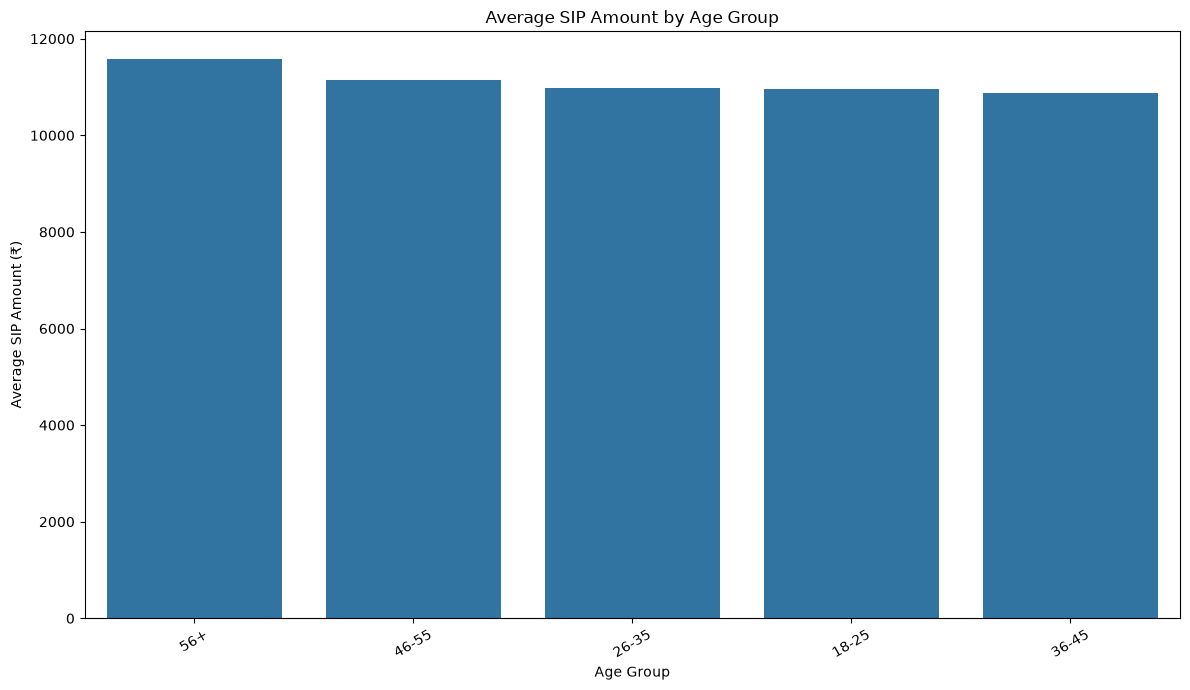

In [14]:
average_sip_age = (
    transactions[
        transactions["transaction_type"] == "SIP"
    ]
    .groupby("age_group", as_index=False)["amount_inr"]
    .mean()
    .sort_values("amount_inr", ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=average_sip_age,
    x="age_group",
    y="amount_inr"
)

plt.title("Average SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average SIP Amount (₹)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(REPORTS_DIR / "eda_average_sip_age.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** Average SIP amounts varied across age groups.

## 12. Return vs Risk

In [15]:
scatter_data = performance.copy()
if "scheme_name" not in scatter_data.columns:
    scatter_data = scatter_data.merge(
        funds[["amfi_code", "scheme_name"]],
        on="amfi_code",
        how="left"
    )

fig = px.scatter(
    scatter_data,
    x="std_dev_ann_pct",
    y="return_3yr_pct",
    size="scheme_aum_crore",
    hover_name="scheme_name",
    title="3-Year Return vs Annualized Risk",
    labels={
        "std_dev_ann_pct": "Annualized Standard Deviation (%)",
        "return_3yr_pct": "3-Year Return (%)",
        "scheme_aum_crore": "AUM (INR Crore)"
    }
)

plt.savefig(REPORTS_DIR / "eda_return_vs_risk.png")
fig.show()

<Figure size 640x480 with 0 Axes>

**Insight:** Average SIP amounts varied across age groups. 

## 13. Top Fund Categories by Net Inflow

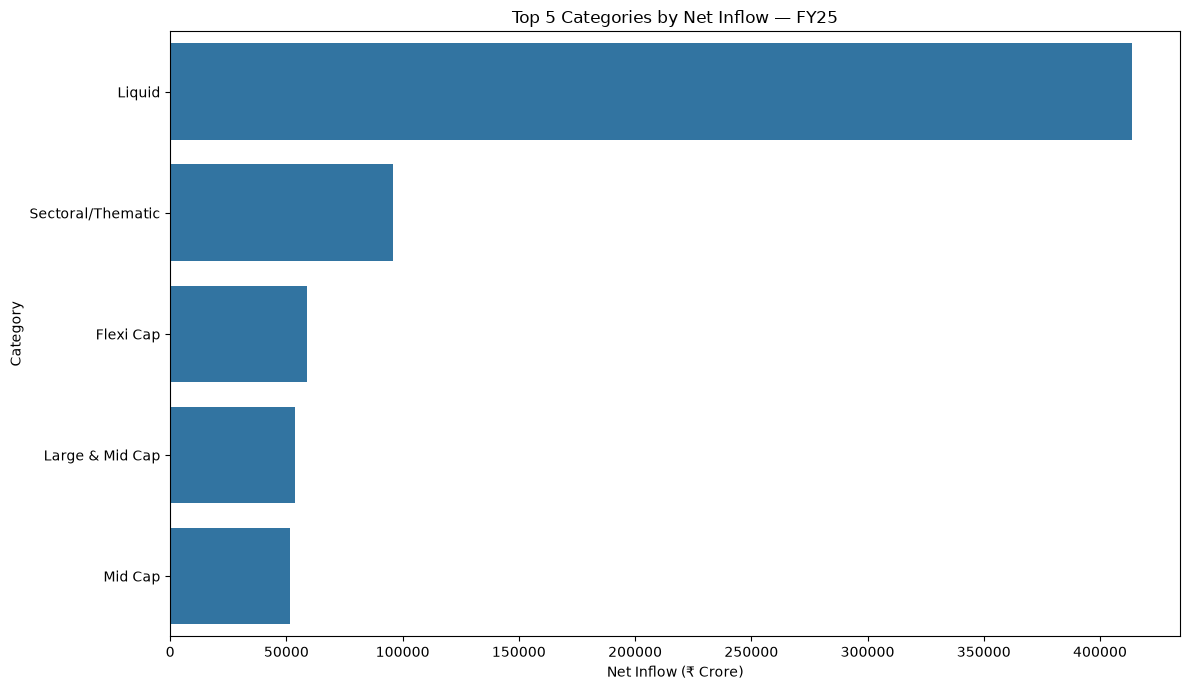

In [16]:
fy25 = category_inflows[
    (category_inflows["month"] >= "2024-04-01") &
    (category_inflows["month"] <= "2025-03-31")
]

top_categories = (
    fy25.groupby("category", as_index=False)["net_inflow_crore"]
    .sum()
    .sort_values("net_inflow_crore", ascending=False)
    .head(5)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_categories,
    x="net_inflow_crore",
    y="category"
)

plt.title("Top 5 Categories by Net Inflow — FY25")
plt.xlabel("Net Inflow (₹ Crore)")
plt.ylabel("Category")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "eda_top5_categories_fy25.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** A few fund categories contributed most of the FY25 net inflows. 

## 14. Top Performing Funds

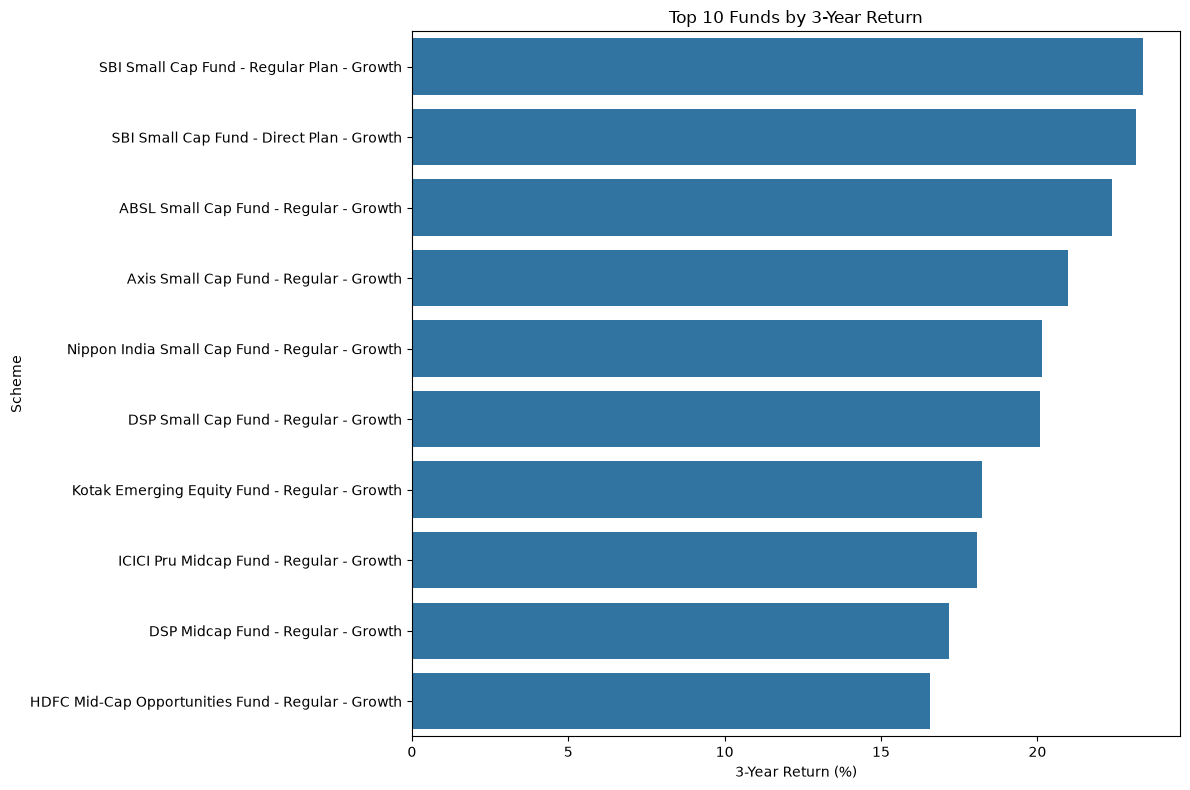

In [17]:
top_returns = performance.copy()
if "scheme_name" not in top_returns.columns:
    top_returns = top_returns.merge(
        funds[["amfi_code", "scheme_name"]],
        on="amfi_code",
        how="left"
    )
top_returns = top_returns.sort_values("return_3yr_pct", ascending=False).head(10)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_returns,
    x="return_3yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 3-Year Return")
plt.xlabel("3-Year Return (%)")
plt.ylabel("Scheme")
plt.tight_layout()

plt.savefig(REPORTS_DIR / "eda_top3yr_returns.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:** The top funds delivered the highest three-year returns in the dataset.

## 20. Key Business Insights
The following findings summarize the most important observations from the exploratory analysis.

In [18]:
latest_aum = aum.sort_values("date").iloc[-1]

aum_by_house = (
    aum.groupby("fund_house")["fund_house_aum_lakh_crore"]
    .sum()
    .sort_values(ascending=False)
)
highest_aum_house = aum_by_house.index[0]
highest_aum_value = aum_by_house.iloc[0]

highest_sip_month = sip.loc[sip["sip_inflow_crore"].idxmax()]
highest_sip_state = sip_state.iloc[0]
highest_sip_age = average_sip_age.iloc[0]
top_return_fund = top_returns.iloc[0]
highest_category = top_categories.iloc[0]
largest_sector = sector_allocation.iloc[0]

print("Highest AUM fund house:", highest_aum_house)
print("Highest AUM value:", round(highest_aum_value, 2), "Lakh Crore")
print("Highest SIP month:", pd.to_datetime(highest_sip_month["month"]).strftime("%B %Y"))
print("Highest SIP inflow:", round(highest_sip_month["sip_inflow_crore"], 2), "Crore")
print("Highest SIP state:", highest_sip_state["state"])
print("Highest SIP state amount:", round(highest_sip_state["amount_inr"], 2))
print("Age group with highest average SIP:", highest_sip_age["age_group"])
print("Average SIP amount:", round(highest_sip_age["amount_inr"], 2))
print("Top 3-year return fund:", top_return_fund["scheme_name"])
print("Top 3-year return:", round(top_return_fund["return_3yr_pct"], 2), "%")
print("Top FY25 category:", highest_category["category"])
print("Top FY25 category inflow:", round(highest_category["net_inflow_crore"], 2), "Crore")
print("Largest sector:", largest_sector["sector"])
print("Largest sector weight:", round(largest_sector["weight_pct"], 2), "%")

Highest AUM fund house: SBI Mutual Fund
Highest AUM value: 84.91 Lakh Crore
Highest SIP month: December 2025
Highest SIP inflow: 31002 Crore
Highest SIP state: Maharashtra
Highest SIP state amount: 16445629
Age group with highest average SIP: 56+
Average SIP amount: 11574.92
Top 3-year return fund: SBI Small Cap Fund - Regular Plan - Growth
Top 3-year return: 23.39 %
Top FY25 category: Liquid
Top FY25 category inflow: 413738.0 Crore
Largest sector: Banking
Largest sector weight: 652.26 %
